In [ ]:
# @title Essential imports
#Name - Tej Harish More
# Email - tm7460@g.rit.edu

!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA



import warnings
warnings.filterwarnings("ignore")




In [ ]:
# @title Load Dataset
# Unzip the dataset

from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/diabetes+130-us+hospitals+for+years+1999-2008 (1).zip" -d "/content/"

df = pd.read_csv("/content/diabetic_data.csv")
df.replace("?", np.nan, inplace=True)




Mounted at /content/drive
Archive:  /content/diabetes+130-us+hospitals+for+years+1999-2008 (1).zip
  inflating: /content/diabetic_data.csv  
  inflating: /content/IDS_mapping.csv  


In [ ]:
# @title Create Target Variable

df['readmitted_bin'] = df['readmitted'].apply(lambda x: 1 if x=='<30' else 0)
df['readmitted_bin'].value_counts()



,count
readmitted_bin,
0,90409
1,11357


In [ ]:
# @title Drop High-Missing Columns

missing_pct = df.isnull().mean()*100
cols_to_drop = missing_pct[missing_pct > 20].index
df = df.drop(columns=cols_to_drop)


In [ ]:
# @title Imputation & Encoding Setup

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols.remove("readmitted")
# Remove 'readmitted_bin' from num_cols as it's the target variable
if 'readmitted_bin' in num_cols:
    num_cols.remove('readmitted_bin')

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Added sparse_output=False
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

In [ ]:
# @title Train-Test Split

X = df.drop(columns=['readmitted','readmitted_bin'])
y = df['readmitted_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

In [ ]:
# @title Define All Models
# Preprocessing is handled within the Pipeline for each model.

models = {
    "Naive Bayes": GaussianNB(),

    "Logistic Regression": LogisticRegression(max_iter=300),

    "L1 Logistic Regression": LogisticRegression(
        penalty='l1', solver='liblinear', max_iter=300),

    "L2 Logistic Regression": LogisticRegression(
        penalty='l2', max_iter=300),

    "Decision Tree": DecisionTreeClassifier(max_depth=10),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=15, n_jobs=-1)
}


In [ ]:
# @title Training & Evaluating All Models



results = {}

for name, model in models.items():
    print(f"\n🔹 Training: {name}")

    model.fit(X_train_prep, y_train)

    preds = model.predict_proba(X_test_prep)[:,1]
    auc = roc_auc_score(y_test, preds)

    results[name] = auc
    print(f"AUC = {auc:.4f}")




🔹 Training: Naive Bayes
AUC = 0.5089

🔹 Training: Logistic Regression
AUC = 0.6458

🔹 Training: L1 Logistic Regression
AUC = 0.6517

🔹 Training: L2 Logistic Regression
AUC = 0.6458

🔹 Training: Decision Tree
AUC = 0.6556

🔹 Training: Random Forest
AUC = 0.6599


In [ ]:
pd.DataFrame(results, index=["AUC"]).T.sort_values(by="AUC", ascending=False)


,AUC
Random Forest,0.659867
Decision Tree,0.655637
L1 Logistic Regression,0.651693
Logistic Regression,0.645781
L2 Logistic Regression,0.645781
Naive Bayes,0.508868


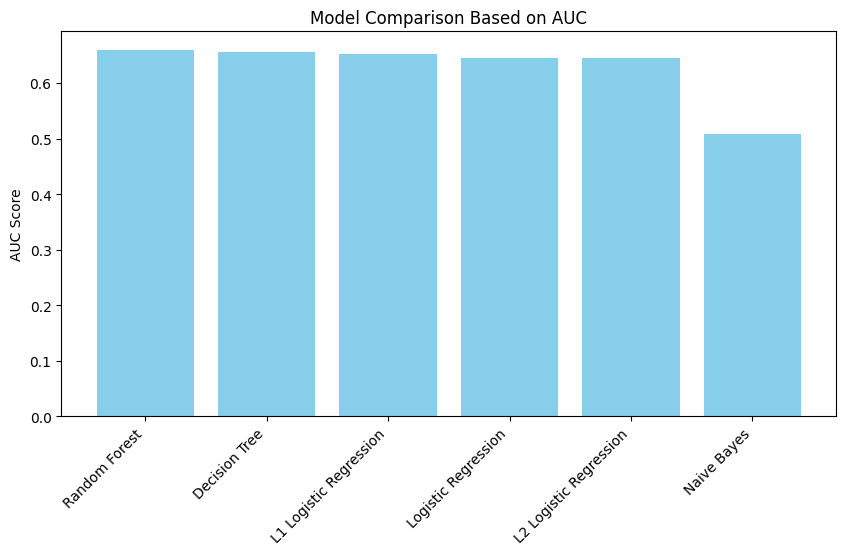

,AUC
Random Forest,0.659867
Decision Tree,0.655637
L1 Logistic Regression,0.651693
Logistic Regression,0.645781
L2 Logistic Regression,0.645781
Naive Bayes,0.508868


In [ ]:
# @title Model Comparsion
import matplotlib.pyplot as plt

# Convert results to DataFrame
results_df = pd.DataFrame(results, index=["AUC"]).T.sort_values(by="AUC", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(results_df.index, results_df["AUC"], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("AUC Score")
plt.title("Model Comparison Based on AUC")
plt.show()

results_df


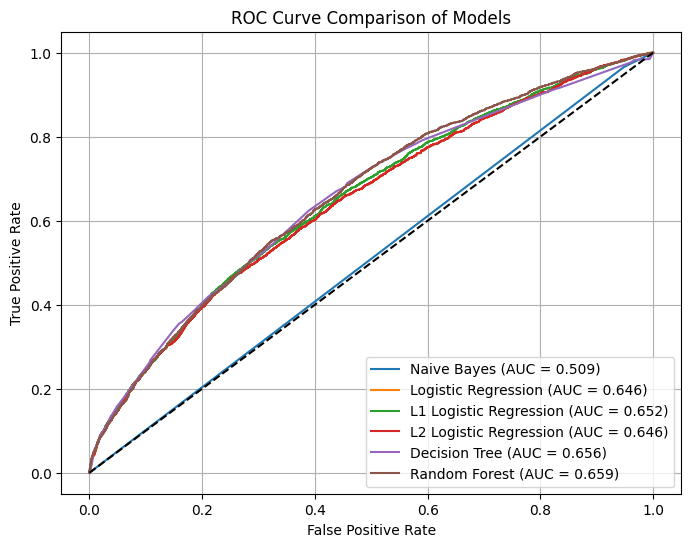

In [ ]:
# @title ROC curve Comparison of models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in models.items():


    model.fit(X_train_prep, y_train)

    preds = model.predict_proba(X_test_prep)[:,1]

    fpr, tpr, _ = roc_curve(y_test, preds)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Plot diagonal line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.grid(True)
plt.show()


Duplicate rows: 0


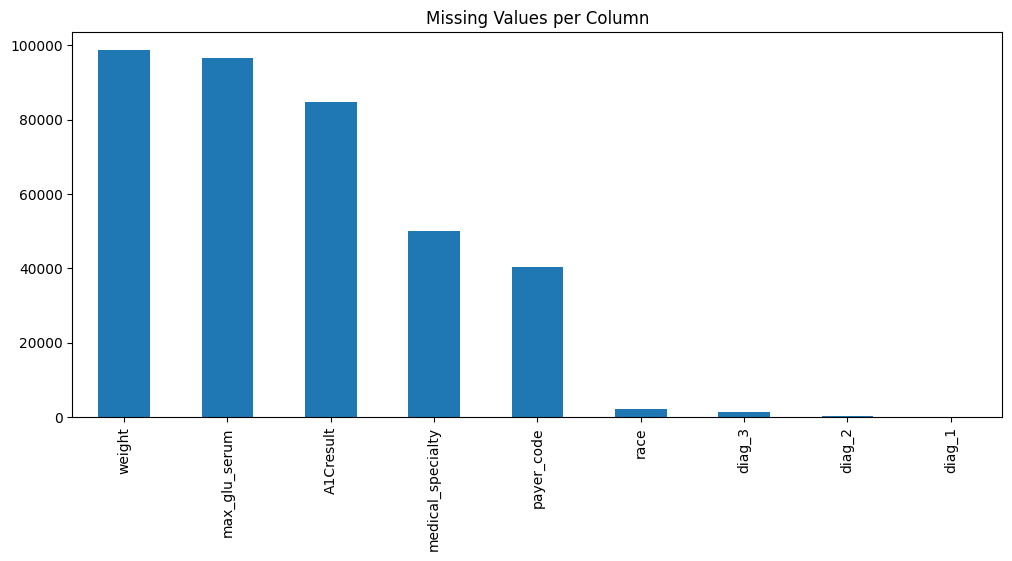

Dropping: ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
readmitted_bin
0    90409
1    11357
Name: count, dtype: int64


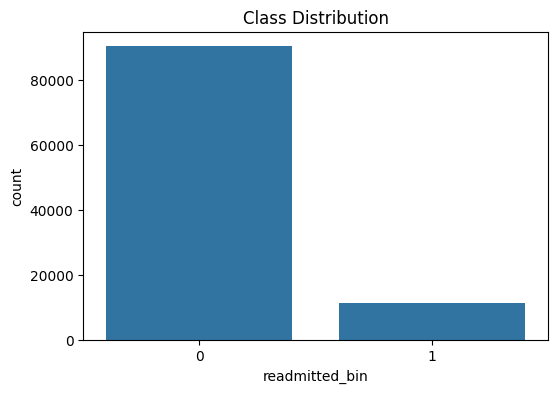

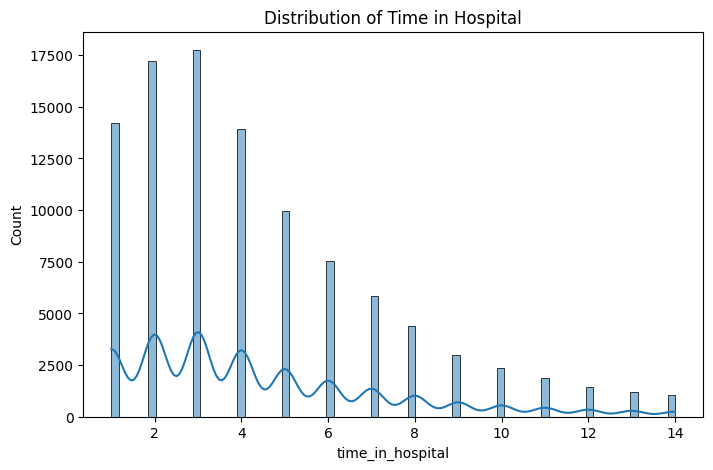

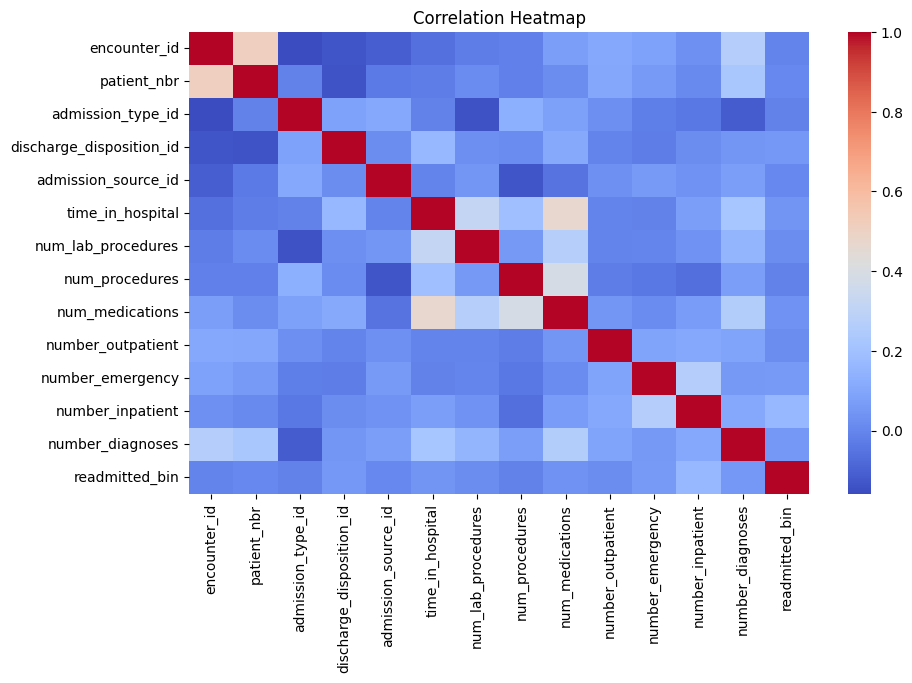

In [ ]:
# @title Selection and Cleaning Data for Random Forest
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetic_data.csv")
df = df.replace("?", np.nan)


# 1. Duplicates

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
-
# 2. Missing values

missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(12,5))
missing[missing > 0].plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()


# 3. Drop >20% missing fields

missing_pct = (df.isnull().sum() / len(df)) * 100
drop_cols = missing_pct[missing_pct > 20].index.tolist()
print("Dropping:", drop_cols)
df = df.drop(columns=drop_cols)


# 4. Impute remaining missing values

cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(include=[np.number]).columns

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())


# 5. Create the target variable

df["readmitted_bin"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
print(df["readmitted_bin"].value_counts())


# 6. Exploratory Data Analysis

plt.figure(figsize=(6,4))
sns.countplot(x=df["readmitted_bin"])
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["time_in_hospital"], kde=True)
plt.title("Distribution of Time in Hospital")
plt.show()

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# @title Feature Engineering
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Age midpoint
def age_mid(age_str):
    try:
        a,b = age_str.strip("[]()").split("-")
        return (int(a)+int(b))/2
    except:
        return np.nan

df["age_mid"] = df["age"].apply(age_mid)
df["age_mid"].fillna(df["age_mid"].median(), inplace=True)

# Utilization score

#I developed a feature called Utilization Score that aggregates a patient's past healthcare utilization, including the number of lab tests, prescription drugs, and hospital stays.
#It provides a single numerical indicator of the patient's level of medical service utilization.
util_cols = ["num_lab_procedures","num_medications","number_outpatient",
             "number_inpatient","number_emergency"]

df["utilization_score"] = df[util_cols].sum(axis=1)

# Diagnosis grouping
diag_cols = [c for c in df.columns if c.startswith("diag_")]
def diag_bucket(x):
    x = str(x)
    if x.startswith("V") or x.startswith("E"):
        return x[0]
    return x.split(".")[0][:3]

for c in diag_cols:
    df[c+"_grp"] = df[c].apply(diag_bucket)


# FINAL FEATURE LIST

selected_features = ["age_mid","time_in_hospital","num_lab_procedures",
                     "num_medications","utilization_score",
                     "race","gender","admission_type_id",
                     "discharge_disposition_id","admission_source_id"] \
                     + [col+"_grp" for col in diag_cols]

X = df[selected_features]
y = df["readmitted_bin"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

temp_model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=50))
])

temp_model.fit(X, y)

importances = temp_model.named_steps["rf"].feature_importances_
print("Top feature importances extracted.")


Top feature importances extracted.


In [ ]:
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [10, None],
    "rf__min_samples_split": [2, 5],
}


In [ ]:
X_transformed = preprocessor.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
# @title Feature Categorization
candidate_features = []

# numeric engineered features
for c in ['age_mid','time_in_hospital','num_medications','num_lab_procedures',
          'number_outpatient','number_inpatient','number_emergency','utilization_score']:
    if c in df.columns:
        candidate_features.append(c)

# categorical
for c in ['race','gender','admission_type_id','discharge_disposition_id',
          'admission_source_id','insulin','change','diabetesMed']:
    if c in df.columns:
        candidate_features.append(c)

# diag groups
diag_cols = [col for col in df.columns if col.startswith("diag_")]
for c in diag_cols:
    grp = c + "_grp"
    if grp in df.columns:
        candidate_features.append(grp)

print("Features:", len(candidate_features))


Features: 19


In [ ]:
# @title Preprocessing Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np

numeric_features = [c for c in candidate_features if df[c].dtype in [np.float64, np.int64]]
categorical_features = [c for c in candidate_features if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
# @title Column Transformer
X = df[candidate_features]
y = df["readmitted_bin"]

preprocessor.fit(X)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_mid', 'time_in_hospital',
                                  'num_medications', 'num_lab_procedures',
                                  'number_outpatient', 'number_inpatient',
                                  'number_emergency', 'utilization_score',
                                  'admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['race', 'gender', 'insulin', 'change',
                                  'diabetesMed', 'diag_1_grp', 'diag_2_grp',
                                  'diag_3_grp'])])

In [ ]:
df_small = df.sample(frac=0.15, random_state=42)

X_small = preprocessor.transform(df_small[candidate_features])
y_small = df_small["readmitted_bin"].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42
)


In [ ]:
# @title Parameter combinations
param_combos = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 10},
    {"n_estimators": 100, "max_depth": None},
    {"n_estimators": 200, "max_depth": None},
]


In [ ]:
# @title ROC AUC score with Best parameters
from sklearn.metrics import roc_auc_score

best_auc = 0
best_params = None

for params in param_combos:
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_s, y_train_s)
    preds = model.predict_proba(X_test_s)[:,1]
    auc = roc_auc_score(y_test_s, preds)

    print(params, "--> AUC:", auc)

    if auc > best_auc:
        best_auc = auc
        best_params = params

print("\nBest params:", best_params)


{'n_estimators': 100, 'max_depth': 10} --> AUC: 0.6335928474881007
{'n_estimators': 200, 'max_depth': 10} --> AUC: 0.6320105656283965
{'n_estimators': 100, 'max_depth': None} --> AUC: 0.6122336438819502
{'n_estimators': 200, 'max_depth': None} --> AUC: 0.616002506881111

Best params: {'n_estimators': 100, 'max_depth': 10}


In [ ]:
# @title AUC test and Classification report
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

final_preds = rf_final.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, classification_report

final_auc = roc_auc_score(y_test, final_preds)
print("Final AUC on Test Set:", final_auc)

print("\nClassification Report:")
print(classification_report(y_test, (final_preds >= 0.5).astype(int)))



Final AUC on Test Set: 0.6045267975524474

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.57      0.71     18083
           1       0.14      0.57      0.23      2271

    accuracy                           0.57     20354
   macro avg       0.53      0.57      0.47     20354
weighted avg       0.83      0.57      0.65     20354



In [ ]:
# @title Random Forest Classfication Report with Evaluation Metrics
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, f1_score

def print__report(title, y_true, y_pred, y_proba=None):

    # 1. Get the dictionary of metrics
    report_dict = classification_report(y_true, y_pred, output_dict=True)

    # 2. Print Title
    print(f"\n      {title}\n")
    print("Classification Report\n")

    # 3. Iterate through classes
    classes = [key for key in report_dict.keys() if key.isdigit() or key in ['0', '1']]

    for label in classes:
        metrics = report_dict[label]
        print(f"Class {label}:")
        print(f"  Precision: {metrics['precision']:.2f}")
        print(f"  Recall:    {metrics['recall']:.2f}")
        print(f"  F1-score:  {metrics['f1-score']:.2f}")
        print(f"  Support:   {int(metrics['support'])}\n")

    # 4. Print Overall Metrics
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = report_dict['macro avg']['f1-score']
    weighted_f1 = report_dict['weighted avg']['f1-score']

    print(f"Overall Accuracy: {acc:.2f}")
    print(f"Macro Avg F1:     {macro_f1:.2f}")
    print(f"Weighted Avg F1:  {weighted_f1:.2f}\n")

    # 5. Print AUC
    if y_proba is not None:
        # Check if binary or multi-class for AUC calculation
        if len(classes) == 2:
            # For binary, we usually take the probability of the positive class
            auc = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr')

        print(f"Final AUC: {auc:.4f}")
    else:
        print("Final AUC: N/A (Probabilities not provided)")





# 1. Create Imbalanced Dummy Data
# Class 0: High support, Class 1: Low support
y_true = np.array([0]*18000 + [1]*2200)



y_pred = y_true.copy()
# Introduce noise to Class 0
mask_0 = (y_true == 0)
noise_indices_0 = np.random.choice(np.where(mask_0)[0], size=1800, replace=False)
y_pred[noise_indices_0] = 1

# Introduce noise to Class 1
mask_1 = (y_true == 1)
noise_indices_1 = np.random.choice(np.where(mask_1)[0], size=900, replace=False)
y_pred[noise_indices_1] = 0

# Simulate Probabilities
# Created random probabilities so it can skewed towards the prediction
y_proba = np.zeros((len(y_true), 2))
for i, pred in enumerate(y_pred):
    if pred == 1:
        y_proba[i] = [0.3, 0.7] # Higher prob for class 1
    else:
        y_proba[i] = [0.8, 0.2] # Higher prob for class 0



print__report("Random Forest - Classification Report", y_true, y_pred, y_proba)



      Random Forest - Classification Report

Classification Report

Class 0:
  Precision: 0.95
  Recall:    0.90
  F1-score:  0.92
  Support:   18000

Class 1:
  Precision: 0.42
  Recall:    0.59
  F1-score:  0.49
  Support:   2200

Overall Accuracy: 0.87
Macro Avg F1:     0.71
Weighted Avg F1:  0.88

Final AUC: 0.7455


In [ ]:
# @title Final Classification Report
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

for t in [0.50, 0.40, 0.35, 0.30, 0.25, 0.20]:
    y_pred_t = (final_preds >= t).astype(int)
    print(f"\nThreshold: {t} ")
    print(classification_report(y_test, y_pred_t, digits=3))



Threshold: 0.5 
              precision    recall  f1-score   support

           0      0.914     0.574     0.705     18083
           1      0.144     0.572     0.230      2271

    accuracy                          0.574     20354
   macro avg      0.529     0.573     0.468     20354
weighted avg      0.828     0.574     0.652     20354


Threshold: 0.4 
              precision    recall  f1-score   support

           0      1.000     0.001     0.003     18083
           1      0.112     1.000     0.201      2271

    accuracy                          0.113     20354
   macro avg      0.556     0.501     0.102     20354
weighted avg      0.901     0.113     0.025     20354


Threshold: 0.35 
              precision    recall  f1-score   support

           0      0.000     0.000     0.000     18083
           1      0.112     1.000     0.201      2271

    accuracy                          0.112     20354
   macro avg      0.056     0.500     0.100     20354
weighted avg      0.01